Compare the results of the akima interpolation with results from a simple linear interpolation in log space. 

In [1]:
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import *
from get_LrLx_data import *
import matplotlib.pyplot as plt

In [2]:
# Akima results
all_data_interp_akima = get_all_LrLx_data(names = None, interp=True, rerun = False, save=False)
print(len(all_data_interp_akima))

Source names:  ['1A 1744-361' '4U 1543-47' '4U 1630-47' 'Cen X-4' 'Cir X-1'
 'EXO 1846-031' 'GRS 1739-278' 'GRS 1915+105' 'GX 339-4' 'H1743-322'
 'IGR J17091-3624' 'MAXI J1348-630' 'MAXI J1631-479' 'MAXI J1803-298'
 'MAXI J1807+132' 'MAXI J1810-222' 'MAXI J1816-195' 'MAXI J1820+070'
 'SAX J1808.4-3658' 'SAX J1810.8-2609' 'Swift J1727.8-1613'
 'Swift J1728.9-3613' 'Swift J1842.5-1124' 'Swift J1858.6-0814'
 'XTE J1701-462']
435


In [3]:
# Get linear interpolation results
all_data_interp_linear = get_all_LrLx_data(names = None, interp=True, rerun = True, save=True, interp_method="linear")
print(len(all_data_interp_linear))

Source names:  ['1A 1744-361' '4U 1543-47' '4U 1630-47' 'Cen X-4' 'Cir X-1'
 'EXO 1846-031' 'GRS 1739-278' 'GRS 1915+105' 'GX 339-4' 'H1743-322'
 'IGR J17091-3624' 'MAXI J1348-630' 'MAXI J1631-479' 'MAXI J1803-298'
 'MAXI J1807+132' 'MAXI J1810-222' 'MAXI J1816-195' 'MAXI J1820+070'
 'SAX J1808.4-3658' 'SAX J1810.8-2609' 'Swift J1727.8-1613'
 'Swift J1728.9-3613' 'Swift J1842.5-1124' 'Swift J1858.6-0814'
 'XTE J1701-462']
435


In [4]:
radio_dates_akima = all_data_interp_akima["t"].to_numpy()
source_names_akima = all_data_interp_akima["name"].to_numpy()
y_predict_akima = all_data_interp_akima["Fx"].to_numpy()
y_predict_err_l_akima = all_data_interp_akima["Fx_unc_l"].to_numpy()
y_predict_err_u_akima = all_data_interp_akima["Fx_unc_u"].to_numpy()

radio_dates_linear = all_data_interp_linear["t"].to_numpy()
source_names_linear = all_data_interp_linear["name"].to_numpy()
y_predict_linear = all_data_interp_linear["Fx"].to_numpy()
y_predict_err_l_linear= all_data_interp_linear["Fx_unc_l"].to_numpy()
y_predict_err_u_linear= all_data_interp_linear["Fx_unc_u"].to_numpy()

In [5]:
mask = radio_dates_akima != radio_dates_linear
print("Number of mismatches:", np.sum(mask))
print("Akima t:", radio_dates_akima[mask])
print("Linear t:", radio_dates_linear[mask])

Number of mismatches: 0
Akima t: []
Linear t: []


<Figure size 1800x700 with 0 Axes>

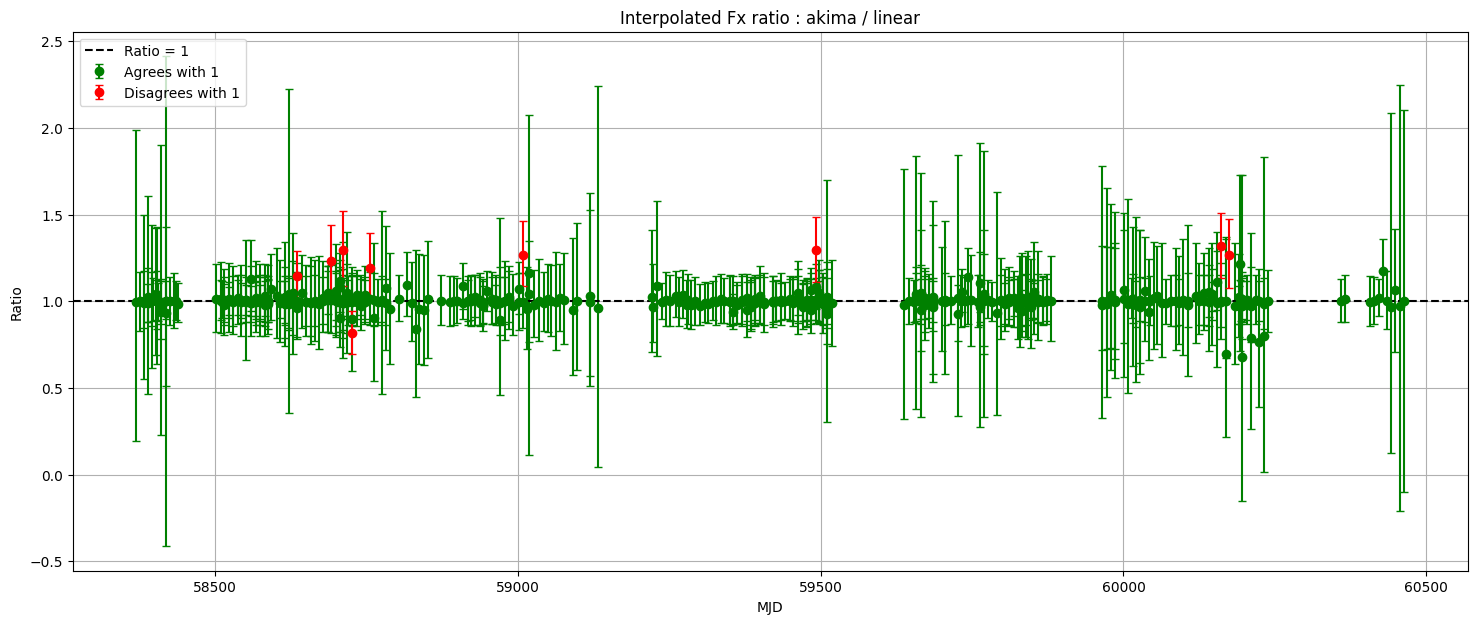

MAXI J1348-630
MAXI J1807+132
MAXI J1820+070
SAX J1808.4-3658
SAX J1810.8-2609
Swift J1842.5-1124


In [6]:
plt.figure(figsize=(18, 7))

Fx_A = y_predict_akima
Fx_B = y_predict_linear 
Fx_A_unc_l = y_predict_err_l_akima
Fx_A_unc_u = y_predict_err_u_akima
Fx_B_unc_l = y_predict_err_l_linear
Fx_B_unc_u = y_predict_err_u_linear

# Ratio and uncertainties
R = Fx_A / Fx_B
R_unc_l = R * np.sqrt((Fx_A_unc_l / Fx_A)**2 + (Fx_B_unc_u / Fx_B)**2)
R_unc_u = R * np.sqrt((Fx_A_unc_u / Fx_A)**2 + (Fx_B_unc_l / Fx_B)**2)

# Check agreement with ratio = 1
R_lower = R - R_unc_l
R_upper = R + R_unc_u
agrees = (R_lower <= 1.0) & (R_upper >= 1.0)
disagrees = ~agrees



### Plot

fig, ax = plt.subplots(figsize=(18, 7))

# Plot agreeing points (green)
ax.errorbar(
    np.array(radio_dates_akima)[agrees], 
    R[agrees], 
    yerr=[R_unc_l[agrees], R_unc_u[agrees]], 
    fmt='o', capsize=3, color='green', label='Agrees with 1'
)

# Plot disagreeing points (red)
ax.errorbar(
    np.array(radio_dates_linear)[disagrees], 
    R[disagrees], 
    yerr=[R_unc_l[disagrees], R_unc_u[disagrees]], 
    fmt='o', capsize=3, color='red', label='Disagrees with 1'
)

# Reference line at ratio = 1
ax.axhline(1.0, color='black', linestyle='--', label='Ratio = 1')

ax.set_xlabel('MJD')
plt.title('Interpolated Fx ratio : akima / linear')
ax.set_ylabel('Ratio')
ax.grid(True)
ax.legend(loc='upper left')

plt.show()

# names of sources where Akima and Linear disagree
disagree_names = np.unique(np.array(source_names_akima)[disagrees])

for name in disagree_names:
    print(name)

MAXI J1348-630
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


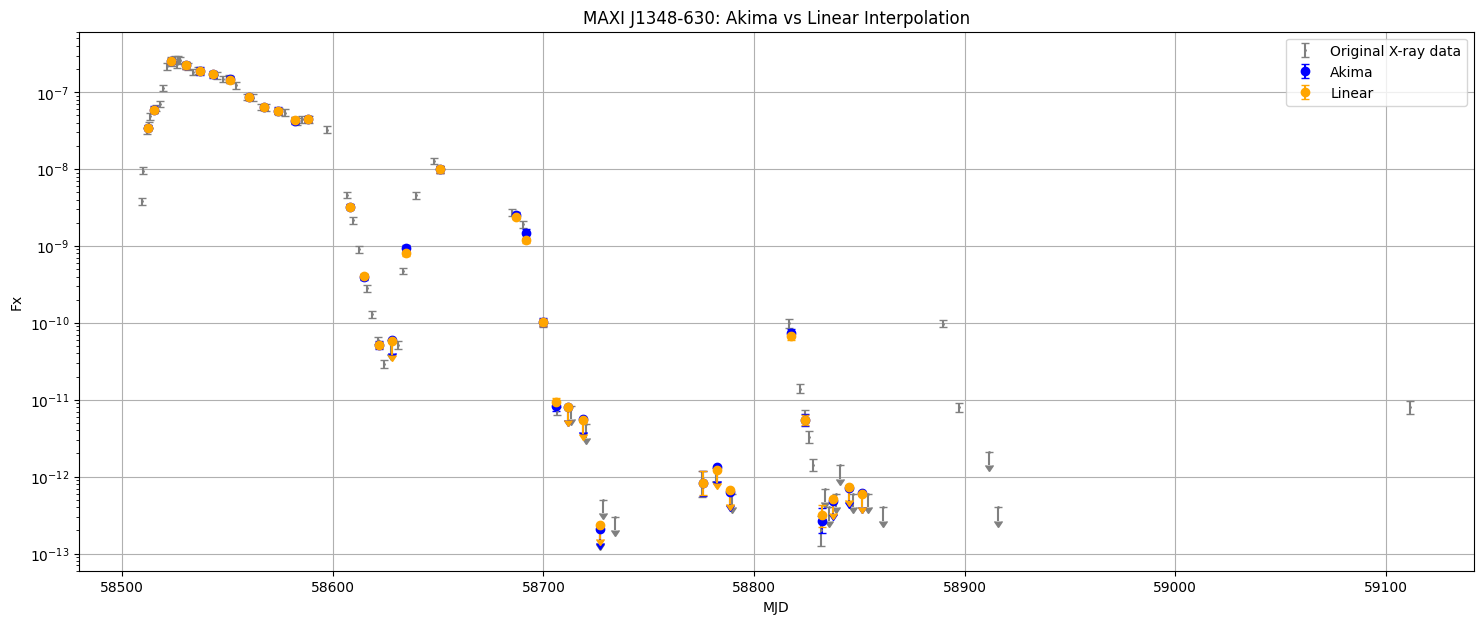

MAXI J1807+132
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


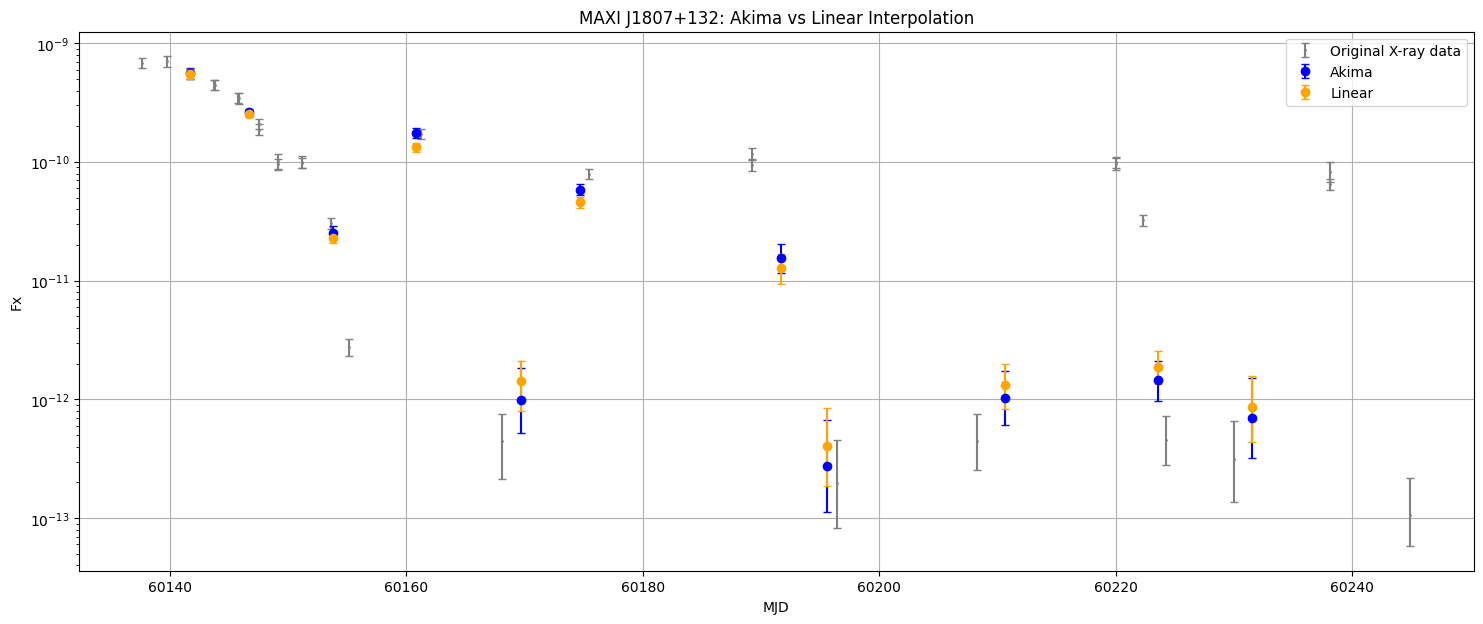

MAXI J1820+070
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


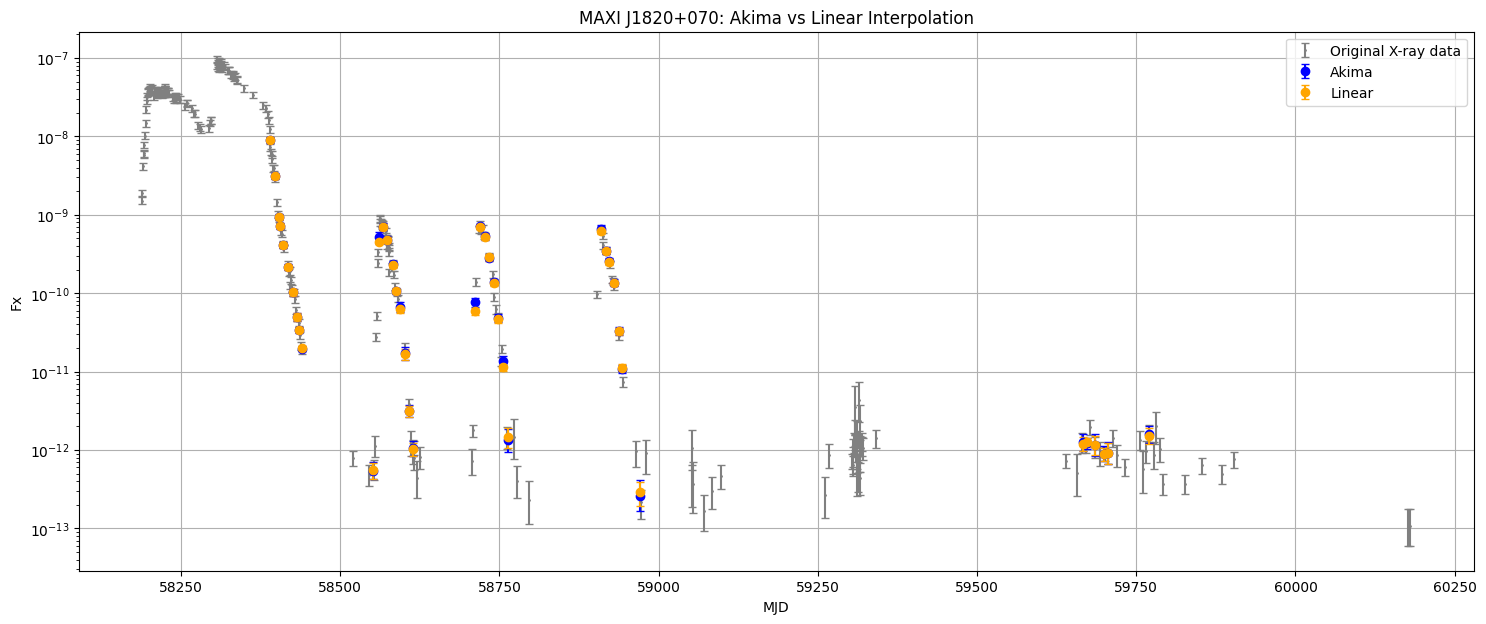

SAX J1808.4-3658
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


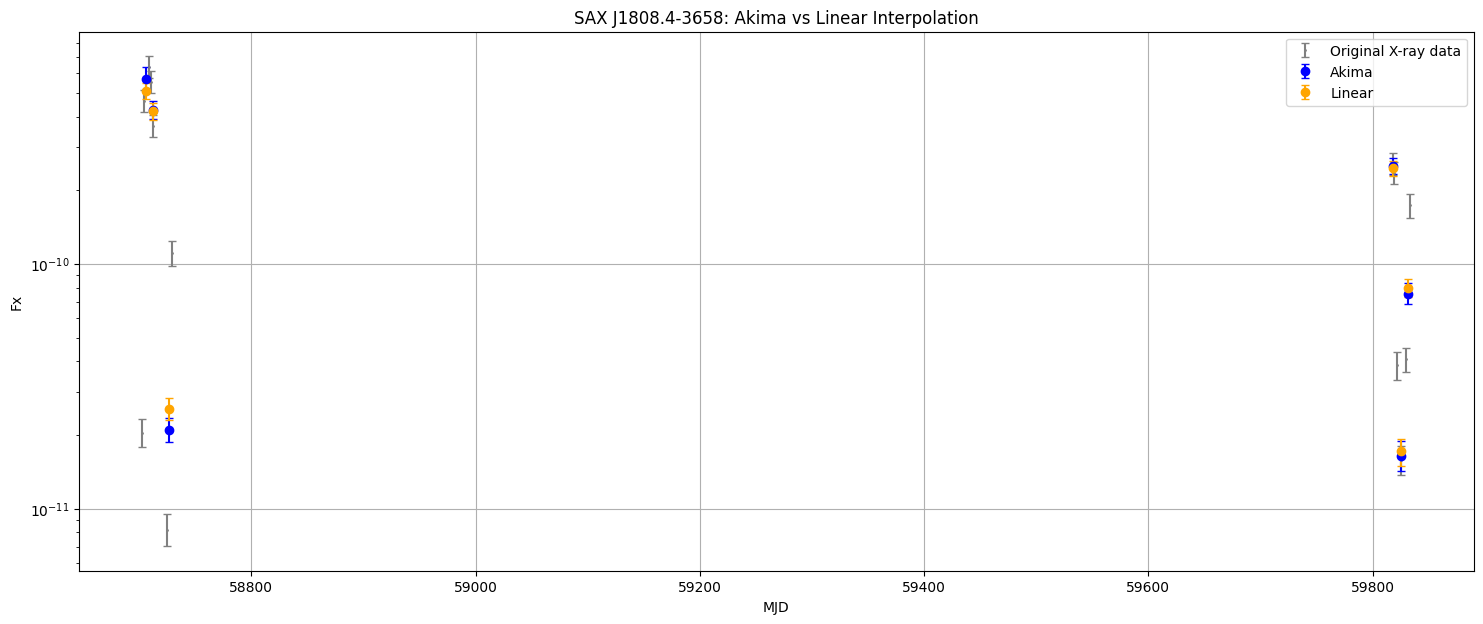

SAX J1810.8-2609
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


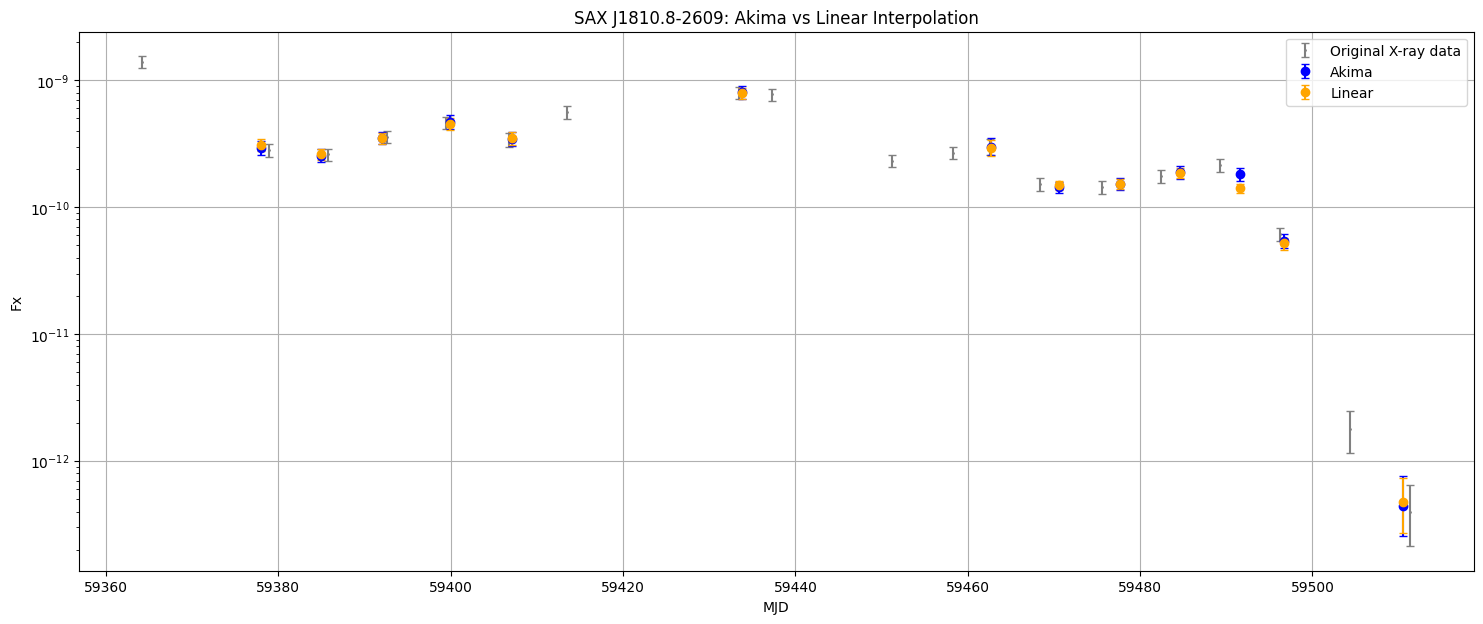

Swift J1842.5-1124
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


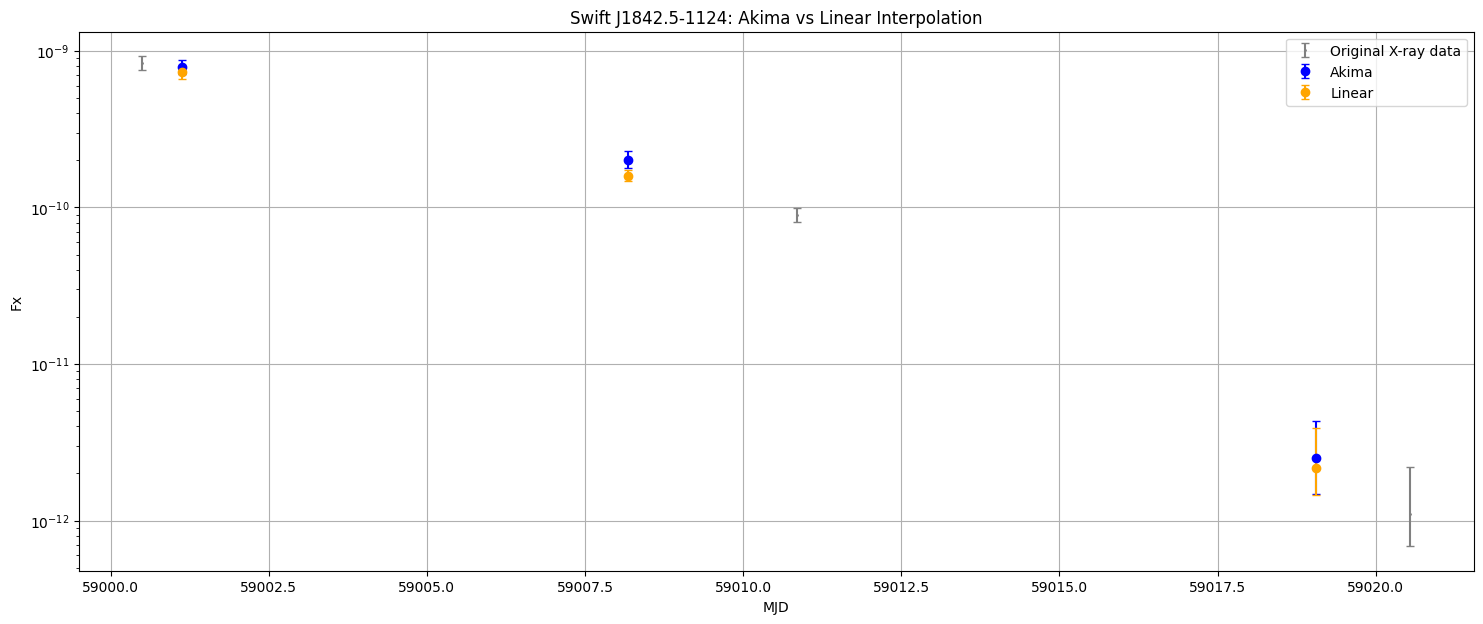

In [7]:
for name in disagree_names:
 
    source_df, obs_df, radio_df, xray_df = read_data(f"../DATA/{name}.txt")
    interpolated_data_akima = make_interpolated_Lr_Lx_df(radio_df, xray_df, source_df, interp_method="akima", save=False, verbose=False)
    interpolated_data_linear = make_interpolated_Lr_Lx_df(radio_df, xray_df, source_df, interp_method="linear", save=False, verbose=False)

    plt.figure(figsize=(18, 7))
    plt.errorbar(xray_df["t_xray"], xray_df["Fx"], yerr=[xray_df["Fx_unc_l"], xray_df["Fx_unc_u"]], fmt='o', uplims = xray_df["Fx_uplim_bool"],  capsize=3, ms=1, color='gray', label='Original X-ray data')
    plt.errorbar(interpolated_data_akima["t"], interpolated_data_akima["Fx"], yerr=[interpolated_data_akima["Fx_unc_l"], interpolated_data_akima["Fx_unc_u"]], uplims = interpolated_data_akima["Fx_uplim_bool"], fmt='o', capsize=3, color='blue', label='Akima')
    plt.errorbar(interpolated_data_linear["t"], interpolated_data_linear["Fx"], yerr=[interpolated_data_linear["Fx_unc_l"], interpolated_data_linear["Fx_unc_u"]], uplims = interpolated_data_linear["Fx_uplim_bool"], fmt='o', capsize=3, color='orange', label='Linear')
    plt.xlabel('MJD')
    plt.ylabel('Fx')
    plt.title(f"{name}: Akima vs Linear Interpolation")
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.show()